## Settings and imports

In [1]:
import sys
sys.path.insert(1, '../src/')
from data_utils import *
from train_and_evaluate import *
from model import *

In [2]:
import json

with open('../config.json', 'r') as f:
    config = json.load(f)

PREPROCESSING_METHOD = config["preprocessing_method"] # normalization / logarithm
HOW_MANY_OUTER_TO_REMOVE = config["how_many_outer_to_remove"]
ELEMENTS_TO_KEEP = config["elements_to_keep"]
MULTIPLICATION_WEIGHTS = config["multiplication_weights"]
DROPOUT_PROB = config["dropout_prob"]

DATA_PATH = config["data_path"]
RESULTS_PATH = config["results_path"]
FIGURES_PATH = config["figures_path"]
MODELS_PATH = config["models_path"]

## Loading the data

In [3]:
inDKs_df, inks_df, inds_df = load_training_data(DATA_PATH)

## Preprocessing

0. Keeping track of the records from the same sample

We will keep this info in 'Sample_id' and 'name' columns.

In [4]:
inDKs_df = create_sample_id(inDKs_df)

1. Let's remove 'outer' samples:

In [5]:
inDKs_df = remove_outer_samples(inDKs_df, HOW_MANY_OUTER_TO_REMOVE)

2. Let's keep only columns that we need.

To reduce the set of used elements run cell below. Then, instead of predicting 29 numbers, we will predict only 10. We will also use only 10 numbers as input.

In [6]:
inDKs_df = delete_elements(inDKs_df, ELEMENTS_TO_KEEP)

3. Let's remove rows with missing values if there are any.

In [7]:
inDKs_df = remove_missing_data(inDKs_df)

4. Let's set negative numbers to zeros. (First, check if there are any.)

In [8]:
inDKs_df = set_negative_to_zero(inDKs_df, ELEMENTS_TO_KEEP)

5. Let's multiply the values by weights.

In [9]:
inDKs_df = multiply_by_weights(inDKs_df, ELEMENTS_TO_KEEP, weights=MULTIPLICATION_WEIGHTS)

6. Normalize with respect to Fe and remove Fe.

In [10]:
# inDKs_df = normalize_to_Fe(inDKs_df, ELEMENTS_TO_KEEP)

### Train test split, datasets, dataloaders

In [11]:
X_y_train, X_y_val, X_y_test = create_partition(inDKs_df)

### Creating features and labels matrices

In [12]:
X_train, y_train, X_val, y_val, X_test, y_test, train_order, val_order, test_order = prepare_data_for_training(
                                                                                                                X_y_train, 
                                                                                                                X_y_val, 
                                                                                                                X_y_test, 
                                                                                                                ELEMENTS_TO_KEEP)

### Normalization / taking logarithm

In [13]:
X_train = transform_data(X_train, 'logarithm')
y_train = transform_data(y_train, 'logarithm')
X_val = transform_data(X_val, 'logarithm')
y_val = transform_data(y_val, 'logarithm')
X_test = transform_data(X_test, 'logarithm')
y_test = transform_data(y_test, 'logarithm')

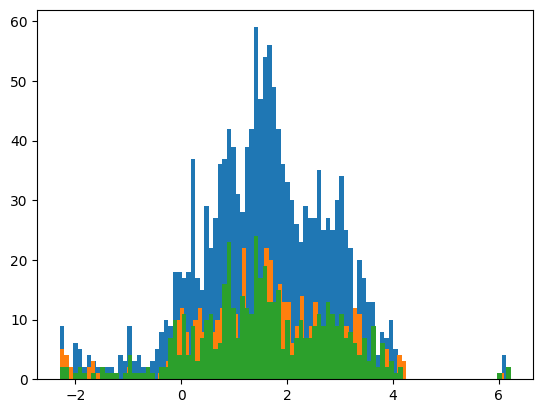

In [14]:
dim = 3
plt.hist(X_train[:,dim], bins=100);
plt.hist(X_val[:,dim], bins=100);
plt.hist(X_test[:,dim], bins=100);

### Converting to tensors

In [15]:
device = get_device()

Using cuda device


In [16]:
X_train = data_to_device(X_train, device)
y_train = data_to_device(y_train, device)
X_val = data_to_device(X_val, device)
y_val = data_to_device(y_val, device)
X_test = data_to_device(X_test, device)
y_test = data_to_device(y_test, device)

### Dataset

In [17]:
train_dataset = InksDataset(X=X_train, y=y_train)
val_dataset = InksDataset(X=X_val, y=y_val)
test_dataset = InksDataset(X=X_test, y=y_test)

In [18]:
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=100)
val_loader = DataLoader(val_dataset, shuffle=True)
test_loader = DataLoader(test_dataset, shuffle=False)

## Neural network

In [19]:
model = InksNet(input_size=INPUT_SIZE, dropout_prob=DROPOUT_PROB).to(device)
print(model)

InksNet(
  (seq): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): Dropout(p=0.1, inplace=False)
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=256, bias=True)
    (5): Dropout(p=0.1, inplace=False)
    (6): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Linear(in_features=256, out_features=1024, bias=True)
    (9): Dropout(p=0.1, inplace=False)
    (10): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Linear(in_features=1024, out_features=256, bias=True)
    (13): Dropout(p=0.1, inplace=False)
    (14): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (15): ReLU()
    (16): Linear(in_features=256, out_features=64, bias=True)
    (17): Dropout(p=0.1, inplace=False)
    (18): BatchNorm1d(64, eps=1e-05

Cu >> Mn > Al > Zn > Pb > S > Cr > Co >>

In [20]:
weights = torch.tensor([1/INPUT_SIZE]*INPUT_SIZE).unsqueeze(1).to(device)
loss_fn = CustomLoss(weights=weights)

In [21]:
# model, train_losses, val_losses = train_model(model=model,
#                                               train_loader=train_loader,
#                                               val_loader=val_loader,
#                                               epochs=5000,
#                                               loss_fn=loss_fn)

### Loss visualisation

In [22]:
#%matplotlib widget

In [23]:
#visualise_losses(train_losses, val_losses)

## Loading pretrained model

In [24]:
model = InksNet(input_size=INPUT_SIZE, dropout_prob=DROPOUT_PROB).to(device)
model.load_state_dict(torch.load(MODELS_PATH))

/tmp/ipykernel_11267/2341782259.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODELS_PATH))


<All keys matched successfully>

## Prediction on test set

In [25]:
labels, outputs, difference, mean_loss = evaluate_on_test_set(model=model, 
                                                              test_loader=test_loader, 
                                                              loss_fn=loss_fn)

Consecutive inks from test set are in labels tensor (498 examples, 10 elements/coordinates):

In [26]:
#labels

Predictions are in out tensor (498 examples, 10 elements/coordinates):

In [27]:
#outputs

Absolute value of difference between true values (labels) and prediction (outputs) are stored in difference tensor (498 examples, 10 elements/coordinates):

In [28]:
#difference

Mean loss:

In [29]:
mean_loss

0.1898058955613748

In [30]:
torch.mean(difference, axis=0)  # 10 elements, new data

tensor([0.1364, 0.1907, 0.3598, 0.1390, 0.2053, 0.1704, 0.2070, 0.1809, 0.1565,
        0.1520], device='cuda:0', grad_fn=<MeanBackward1>)

Consecutive coordinates correspond to: Al, S, Cr, Mn, Co, Cu, Zn, Pb, Fe, Mg.

Significance of elements: Cu >> Mn > Al > Zn > Pb > S > Cr > Co >> all the others.

## Saving the model

In [31]:
# save_model(model, MODELS_PATH, HOW_MANY_OUTER_TO_REMOVE, 
#                 ELEMENTS_TO_KEEP, PREPROCESSING_METHOD)

### Visualisations

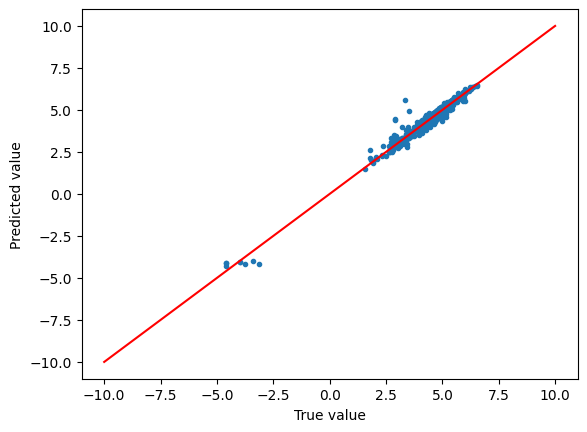

In [28]:
visualise_prediction_against_true(outputs, labels, dimension=9)

## Quality of prediction: closest points

### Creating df with means of classes

In [31]:
mean_df = create_means_df(ELEMENTS_TO_KEEP, y_train.cpu(), train_order, y_val.cpu(), val_order)

### Checking if there is any chance for it to work: if classes in y_test are close to means of classes in train_val set

In [32]:
y_test_df, consistency = find_and_compare_closest_class(y_test.cpu(), test_order, ELEMENTS_TO_KEEP, mean_df)

In [33]:
consistency

0.9658634538152611

### Now let's check if it works for the neural network's output.

In [34]:
model.eval()
outputs = model(X_test)

In [35]:
outputs_df, accuracy = find_and_compare_closest_class(outputs.cpu().detach().numpy(), test_order, ELEMENTS_TO_KEEP, mean_df)

In [36]:
accuracy = compute_accuracy(outputs_df)

Accuracy: 90.2%.


In [37]:
precision, recall = compute_precision_and_recall(outputs_df)

Precision: 0.9254805591961556
Recall: 0.9107142857142857


/home/basia/Documents/atramenty/inks_repo/notebooks/../src/train_and_evaluate.py:193: RuntimeWarning: invalid value encountered in divide
  precision = tp / tp_and_fp
/home/basia/Documents/atramenty/inks_repo/notebooks/../src/train_and_evaluate.py:194: RuntimeWarning: invalid value encountered in divide
  recall = tp / tp_and_fn


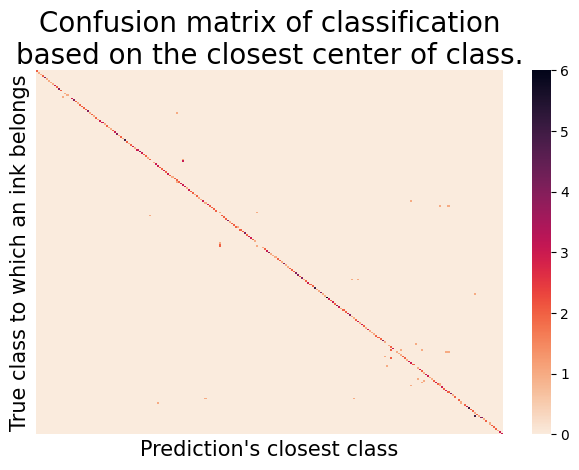

In [38]:
plot_confusion_matrix(true_labels = outputs_df['Real sample_id'], 
                      closest_labels = outputs_df['Closest sample id'], 
                      normalization_in_conf_mat = None, 
                      path_to_save = None)

## Quality of prediction: confidence intervals

In [39]:
model.eval()
outputs = model(X_test)

In [40]:
min_df, max_df, min_max_df = create_min_max_df(y_train.cpu(), 
                                               train_order, 
                                               y_val.cpu(), 
                                               val_order, 
                                               ELEMENTS_TO_KEEP)

In [41]:
lower_bound_df, upper_bound_df = create_mean_plus_sd_df(y_train.cpu(), 
                                                        train_order, 
                                                        y_val.cpu(), 
                                                        val_order, 
                                                        ELEMENTS_TO_KEEP, 
                                                        how_many_sd=2)

In [46]:
min_max_res_list, fraction_1 = is_inside_min_max_interval(outputs, test_order, min_df, max_df)

In [47]:
sd_res_list, fraction_2 = is_inside_mean_plus_minus_sd_interval(outputs, test_order, lower_bound_df, upper_bound_df)

Percentage of points inside min-max interval:

In [48]:
fraction_1

np.float64(0.728714859437751)

On consecutive coordinates:

In [49]:
np.array(min_max_res_list).mean(0)

array([[0.71285141, 0.75100402, 0.85140562, 0.73293173, 0.76305221,
        0.63855422, 0.70883534, 0.71485944, 0.67670683, 0.73694779]])

Percentage of points inside mean +- 2 standard deviations interval:

In [50]:
fraction_2

np.float64(0.8453815261044176)

On consecutive coordinates:

In [51]:
np.array(sd_res_list).mean(0)

array([[0.82730924, 0.86947791, 0.91967871, 0.85542169, 0.85341365,
        0.79116466, 0.84337349, 0.82329317, 0.8373494 , 0.83333333]])

### Visualisations of min-max intervals

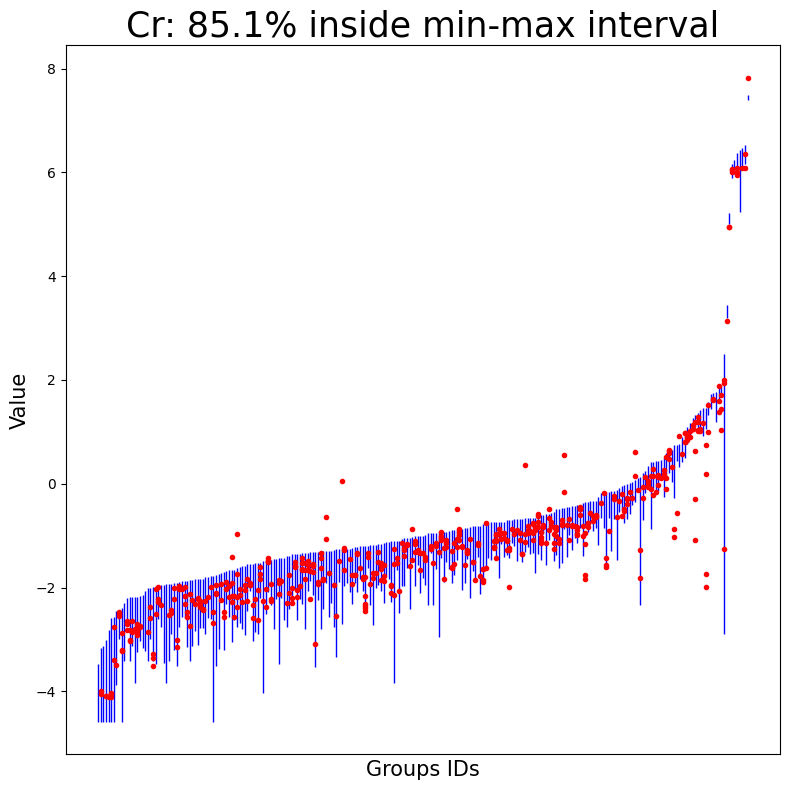

In [52]:
visualise_min_max_intervals(outputs, 
                            test_order, 
                            ELEMENTS_TO_KEEP, 
                            min_max_df, 
                            min_max_res_list, 
                            element_nr=2, 
                            path_to_save=None)

### Visualisations of mean +- 2 * standard deviation intervals

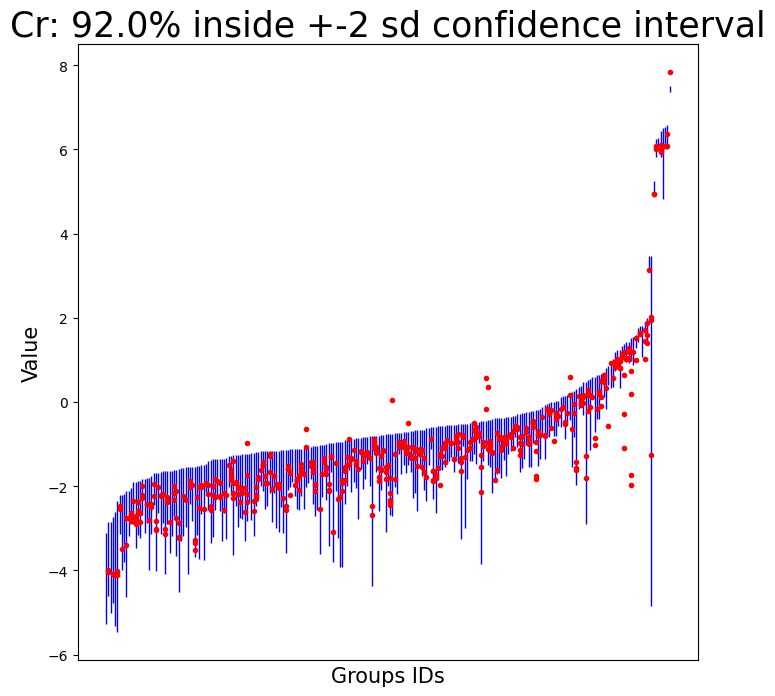

In [53]:
visualise_mean_plus_minus_sd_intervals(outputs, 
                                       test_order, 
                                        ELEMENTS_TO_KEEP, 
                                       lower_bound_df, 
                                       upper_bound_df, 
                                       how_many_sd=2,
                                       sd_res_list=sd_res_list, 
                                       element_nr=2, 
                                       path_to_save=None)

## Interpretability